# Phase 2.1: Indoor PM2.5 Forecasting (Exploration & Tuning)

This notebook outlines the exploratory data analysis, feature selection, and hyperparameter tuning required to construct the predictive models. The exploratory phase is separated from final evaluation to prevent data leakage.

## Objectives
1. **Data Splitting:** Chronologically partition the dataset into Training (70%), Validation (10%), and Testing (20%) sets to preserve temporal continuity.
2. **Feature Selection:** Identify the predictive feature subset across all building environments.
3. **Meteorological Ablation:** Validate whether meteorological variables (temperature, humidity) empirically improve forecasting accuracy.
4. **Lookback Window Analysis:** Evaluate the historical sequence window across extended durations (up to 12 hours) to capture physical infiltration dynamics.
5. **Hyperparameter Tuning:** Execute a, 8-fold Walk Forward randomised search to optimise architecture for XGBoost and LSTM models.

## 1. Environment Configuration

Core libraries are loaded for data manipulation, machine learning (XGBoost), deep learning (TensorFlow/Keras), and evaluation.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from xgboost import XGBRegressor
from sklearn.multioutput import MultiOutputRegressor
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Global scope variables for pair configuration
pair_configs = {
    'Pair_A': {'in_pm': 'node_2_pm25', 'out_pm': 'node_1_dry', 'out_humi': 'node_1_humi', 'out_t': 'node_1_temp', 'in_humi': 'node_2_humi', 'in_t': 'node_2_temp'},
    'Pair_B': {'in_pm': 'node_4_pm25', 'out_pm': 'node_3_dry', 'out_humi': 'node_3_humi', 'out_t': 'node_3_temp', 'in_humi': 'node_4_humi', 'in_t': 'node_4_temp'},
    'Pair_C_Pre': {'in_pm': 'node_7_pm25', 'out_pm': 'node_6_dry', 'out_humi': 'node_6_humi', 'out_t': 'node_6_temp', 'in_humi': 'node_7_humi', 'in_t': 'node_7_temp'},
    'Pair_C_Post': {'in_pm': 'node_7_pm25', 'out_pm': 'node_6_dry', 'out_humi': 'node_6_humi', 'out_t': 'node_6_temp', 'in_humi': 'node_7_humi', 'in_t': 'node_7_temp'}
}

## 2. Data Ingestion & Hourly Aggregation

The raw calibrated datasets (LCS) are re-sampled to 1-hour intervals. Missing values (`NaN`s) are retained within the continuous timeline. No interpolation is applied; missing values are retained to maintain the physical validity of the observations. Any generated tensor sequences containing `NaN` values will be dropped downstream prior to model training.

In [ ]:
# Ingest 1-minute calibrated dataset
try:
    df_raw = pd.read_csv('../data/04_calibrated_master/calibrated_master_1min.csv', parse_dates=['timestamp_utc'], index_col='timestamp_utc')
except FileNotFoundError:
    print("Dataset not found. Please ensure the CSV is located at ../data/04_calibrated_master/calibrated_master_1min.csv")
    df_raw = pd.DataFrame() # Fallback for structural testing


# --- WIND DATA INJECTION (EGLC) ---
df_weather = pd.read_csv('../data/01_raw/exo_filter/EGLC.csv', parse_dates=['valid'], index_col='valid')
df_weather = df_weather[['sped', 'drct']].copy()
df_weather['wind_speed_ms'] = df_weather['sped'] * 0.44704
# Calculate vector components for circular wind direction
df_weather['wind_sin'] = np.sin(np.radians(df_weather['drct']))
df_weather['wind_cos'] = np.cos(np.radians(df_weather['drct']))
df_weather.drop(columns=['sped', 'drct'], inplace=True)
    
df_weather.index = df_weather.index.tz_localize('UTC')
# Resample weather to 1 hour
weather_hourly = df_weather.resample('1h').mean()
# ---------------------------

if not df_raw.empty:
    hourly_datasets = {}
    for name, config in pair_configs.items():
        # Ensure only existing columns are extracted to prevent KeyError
        cols = list(set([c for c in config.values() if c in df_raw.columns]))
        
        # Segment Pair C based on the established relocation event timeline
        if name == 'Pair_C_Pre':
            df_sub = df_raw[df_raw.index <= '2025-06-16 12:30:00'][cols].copy()
        elif name == 'Pair_C_Post':
            df_sub = df_raw[df_raw.index >= '2025-06-19 14:00:00'][cols].copy()
        else:
            df_sub = df_raw[cols].copy()
            
        # Re-sample to macroscopic 1-hour intervals, strictly retaining NaNs
        df_hourly = df_sub.resample('1h').mean()
        
        # Merge weather data
        df_hourly = df_hourly.join(weather_hourly, how='left')
        
        # Append cyclic temporal vectors
        df_hourly['hour_sin'] = np.sin(2 * np.pi * df_hourly.index.hour / 24.0)
        df_hourly['hour_cos'] = np.cos(2 * np.pi * df_hourly.index.hour / 24.0)
        df_hourly['day_sin'] = np.sin(2 * np.pi * df_hourly.index.dayofweek / 7.0)
        df_hourly['day_cos'] = np.cos(2 * np.pi * df_hourly.index.dayofweek / 7.0)
        
        hourly_datasets[name] = df_hourly

    print("Data ingested, re-sampled to 1-hour intervals, and temporal vectors appended.")

Data ingested, re-sampled to 1-hour intervals, and temporal vectors appended.


## 3. Chronological Data Splitting

The timeline for each environment (Pair A, Pair B, Pair C-Pre, Pair C-Post) is partitioned based on chronological order: 70% Training, 10% Validation, and 20% Testing. The splits are exported to an external directory.

In [3]:
def split_and_export(df, pair_name):
    # Calculate indices based on absolute chronological length
    n = len(df)
    train_idx = int(n * 0.7)
    val_idx = int(n * 0.8)
    
    train = df.iloc[:train_idx]
    val = df.iloc[train_idx:val_idx]
    test = df.iloc[val_idx:]
    
    # Establish protected sub-directories
    os.makedirs(f'../data/05_forecasting/train', exist_ok=True)
    os.makedirs(f'../data/05_forecasting/val', exist_ok=True)
    os.makedirs(f'../data/05_forecasting/test', exist_ok=True)
    
    # Export splits to isolate test data
    train.to_csv(f'../data/05_forecasting/train/{pair_name}_train.csv')
    val.to_csv(f'../data/05_forecasting/val/{pair_name}_val.csv')
    test.to_csv(f'../data/05_forecasting/test/{pair_name}_test.csv')
    print(f"{pair_name:15} | Train: {len(train):4d} hrs | Val: {len(val):4d} hrs | Test: {len(test):4d} hrs")

if 'hourly_datasets' in locals():
    print("Executing Chronological Splits:")
    for name, df in hourly_datasets.items():
        split_and_export(df, name)

Executing Chronological Splits:
Pair_A          | Train: 7072 hrs | Val: 1011 hrs | Test: 2021 hrs
Pair_B          | Train: 7072 hrs | Val: 1011 hrs | Test: 2021 hrs
Pair_C_Pre      | Train: 1033 hrs | Val:  148 hrs | Test:  296 hrs
Pair_C_Post     | Train: 5987 hrs | Val:  856 hrs | Test: 1711 hrs


## 4. Tensor Sequence Generation

Function to construct sequence matrices. A sliding window ingests $t-x$ through $t$ to predict $t+1, t+2, t+3$. If any `NaN` values are detected within a sequence, that specific sequence is discarded to guarantee empirical continuity.

In [4]:
def create_sequences(df, feature_cols, target_col, lookback=1, horizons=3):
    X, y = [], []
    # Convert dataframe to raw numpy arrays to bypass slow pandas iteration
    data = df[feature_cols].values
    target = df[target_col].values
    
    # Iterate through timeline, ensuring enough remaining rows exist to satisfy both the lookback and future horizon
    for i in range(len(df) - lookback - horizons + 1):
        x_seq = data[i:(i + lookback)]                             # Historical context block (e.g. t-x to t)
        y_seq = target[(i + lookback):(i + lookback + horizons)]   # Future prediction block (e.g. t+1, t+2, t+3)
        
        # Discard sequence if any NaN exists in either the historical or future block
        if np.isnan(x_seq).any() or np.isnan(y_seq).any():
            continue
            
        X.append(x_seq)
        y.append(y_seq)
        
    return np.array(X), np.array(y)

def unscale_matrix(matrix, scaler):
    res = np.zeros_like(matrix)
    for i in range(matrix.shape[1]):
        res[:, i] = scaler.inverse_transform(matrix[:, i].reshape(-1, 1)).flatten()
    return res

## 5. Feature Selection Audit

A baseline XGBoost model is fitted to the training data of each environment to extract F-Scores, isolating the features with the highest F-Scores. The visualisation indicates that historical indoor PM2.5 concentrations hold the highest preditive power out of the entire featureset by a large margin. 

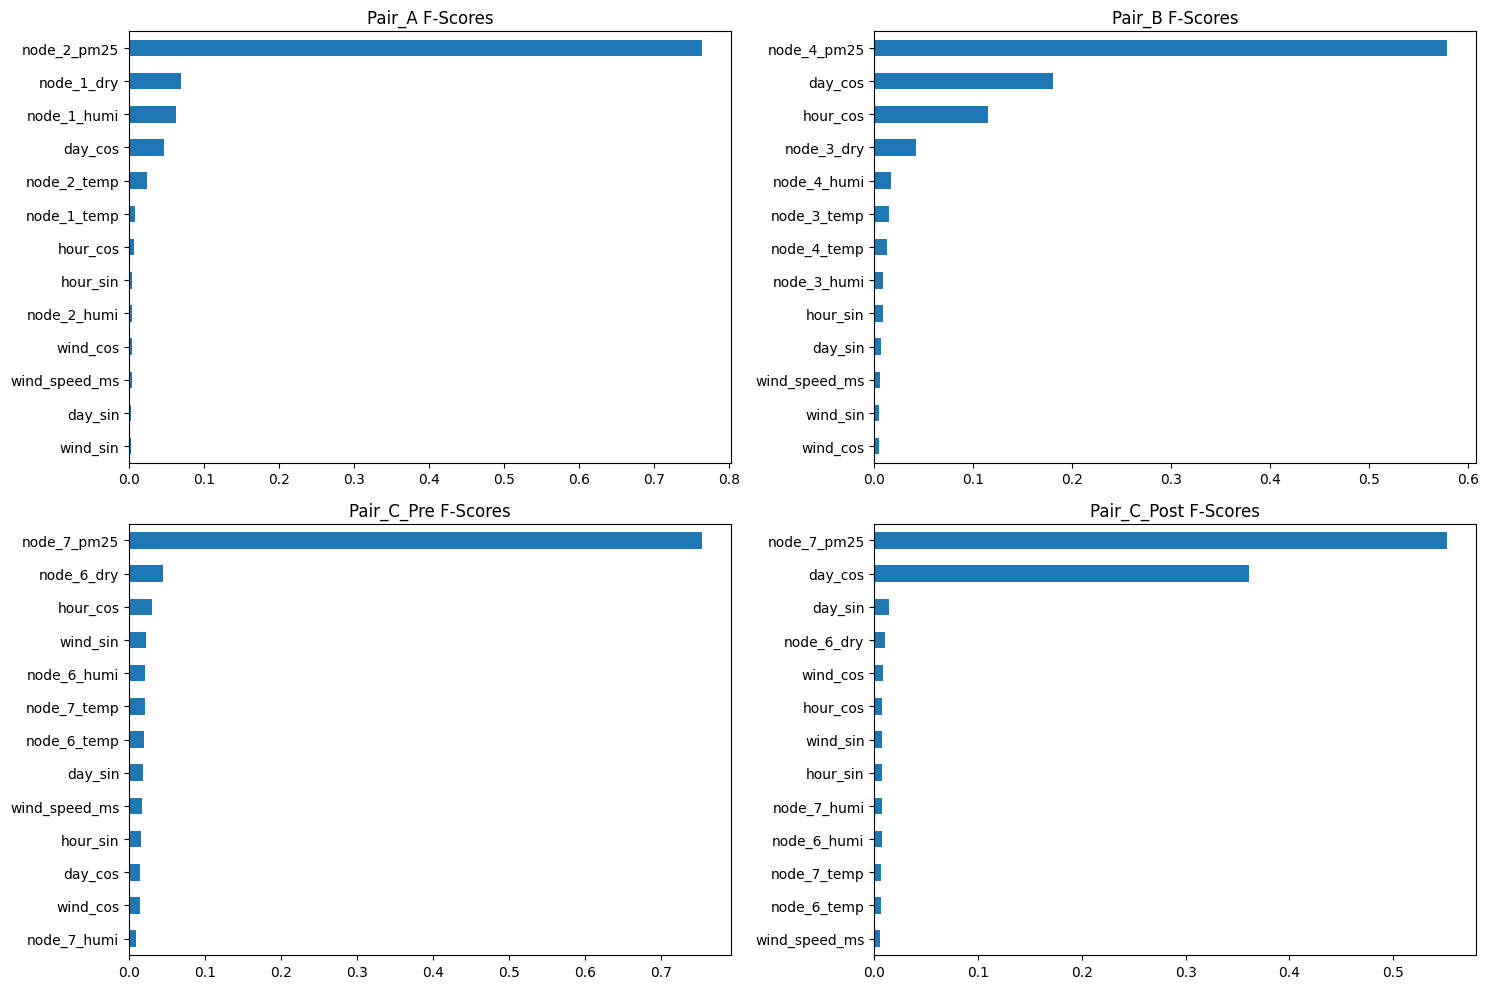

In [5]:
if 'hourly_datasets' in locals():
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    for idx, (name, config) in enumerate(pair_configs.items()):
        try:
            train_df = pd.read_csv(f'../data/05_forecasting/train/{name}_train.csv', index_col='timestamp_utc', parse_dates=True)
            
            target = config['in_pm']
            features = [target] + [c for c in train_df.columns if c != target]
            
            # Generate 1-hour lookback sequence for feature testing
            X_train, y_train = create_sequences(train_df, features, target, lookback=1, horizons=1)
            
            if len(X_train) > 0:
                # Flatten X from (samples, 1, features) to (samples, features) for XGBoost
                X_train_flat = X_train.reshape(X_train.shape[0], X_train.shape[2])
                
                model = XGBRegressor(n_estimators=50, random_state=42)
                model.fit(X_train_flat, y_train)
                
                importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=True)
                importance.plot(kind='barh', ax=axes[idx], title=f"{name} F-Scores")
        except FileNotFoundError:
            pass
            
    plt.tight_layout()
    plt.show()

## 6. Lookback Window Evaluation

Extending the historical context captures slower building infiltration dynamics (ACH) but increases the likelihood of encountering `NaN` values within the sequence, thereby reducing viable training data. This evaluation tests all individual hourly windows from 1 hour up to 12 hours. It is executed using the Full Feature Set to ensure all physical meteorological variables are given adequate time to demonstrate predictive lag.

In [ ]:
def evaluate_lookback():
    print("Lookback Window Audit (All Pairs - Multi-Horizon t+1, t+2, t+3)\n" + "-"*85)
    results_list = []
    
    for name, config in pair_configs.items():
        try:
            train_df = pd.read_csv(f'../data/05_forecasting/train/{name}_train.csv', index_col=0)
            val_df = pd.read_csv(f'../data/05_forecasting/val/{name}_val.csv', index_col=0)
            
            target = config['in_pm']
            time_cols = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos']
            out_pm = config['out_pm']
            
            met_cols = [c for c in [config.get('in_humi'), config.get('in_t'), config.get('out_humi'), config.get('out_t'), 'wind_speed_ms', 'wind_sin', 'wind_cos'] if c in train_df.columns]
            features = [target, out_pm] + met_cols + time_cols
            
            scaler = MinMaxScaler()
            target_scaler = MinMaxScaler()
            train_scaled, val_scaled = train_df.copy(), val_df.copy()
            # Fit scaler strictly on the training set to prevent data leakage into validation metrics
            train_scaled[features] = scaler.fit_transform(train_df[features])
            val_scaled[features] = scaler.transform(val_df[features])
            target_scaler.fit(train_df[[target]])
            
            for w in range(1, 13):
                # Construct 3D tensor sequences for the current window size
                X_train, y_train = create_sequences(train_scaled, features, target, lookback=w, horizons=3)
                X_val, y_val = create_sequences(val_scaled, features, target, lookback=w, horizons=3)
                
                if len(X_train) == 0 or len(X_val) == 0: continue
                
                # --- XGBoost Evaluation (Multi-Output) ---
                # XGBoost requires 2D tabular data, so we flatten the 3D tensor (samples, timesteps, features)
                X_train_xgb = X_train.reshape(X_train.shape[0], X_train.shape[1] * X_train.shape[2])
                X_val_xgb = X_val.reshape(X_val.shape[0], X_val.shape[1] * X_val.shape[2])
                
                # MultiOutputRegressor automatically wraps the base XGBoost model to train 3 independent regressors
                xgb_base = XGBRegressor(n_estimators=50, random_state=42)
                xgb_model = MultiOutputRegressor(xgb_base)
                xgb_model.fit(X_train_xgb, y_train)
                xgb_preds = xgb_model.predict(X_val_xgb)
                
                y_val_unscaled = unscale_matrix(y_val, target_scaler)
                xgb_preds_unscaled = unscale_matrix(xgb_preds, target_scaler)
                
                xgb_rmse_1 = np.sqrt(mean_squared_error(y_val_unscaled[:, 0], xgb_preds_unscaled[:, 0]))
                xgb_rmse_2 = np.sqrt(mean_squared_error(y_val_unscaled[:, 1], xgb_preds_unscaled[:, 1]))
                xgb_rmse_3 = np.sqrt(mean_squared_error(y_val_unscaled[:, 2], xgb_preds_unscaled[:, 2]))
                
                # --- LSTM Evaluation (MIMO) ---
                # The LSTM naturally accepts the 3D tensor natively without flattening
                lstm_model = Sequential([
                    Input(shape=(X_train.shape[1], X_train.shape[2])),
                    LSTM(32),
                    Dense(3)
                ])
                lstm_model.compile(optimizer='adam', loss='mse')
                lstm_model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
                lstm_preds = lstm_model.predict(X_val, verbose=0)
                lstm_preds_unscaled = unscale_matrix(lstm_preds, target_scaler)
                
                lstm_rmse_1 = np.sqrt(mean_squared_error(y_val_unscaled[:, 0], lstm_preds_unscaled[:, 0]))
                lstm_rmse_2 = np.sqrt(mean_squared_error(y_val_unscaled[:, 1], lstm_preds_unscaled[:, 1]))
                lstm_rmse_3 = np.sqrt(mean_squared_error(y_val_unscaled[:, 2], lstm_preds_unscaled[:, 2]))
                
                results_list.append({
                    'Pair': name, 'Window': w, 'Viable_Seqs': len(X_train),
                    'XGB_t1': xgb_rmse_1, 'XGB_t2': xgb_rmse_2, 'XGB_t3': xgb_rmse_3,
                    'LSTM_t1': lstm_rmse_1, 'LSTM_t2': lstm_rmse_2, 'LSTM_t3': lstm_rmse_3
                })
                
        except FileNotFoundError:
            pass

    df_results = pd.DataFrame(results_list)
    os.makedirs('../data/06_outputs/phase2.1', exist_ok=True)
    df_results.to_csv('../data/06_outputs/phase2.1/lookback_audit_results.csv', index=False)
    
    optimal_xgb = {}
    optimal_lstm = {}
    if not df_results.empty:
        idx_mins_xgb = df_results.groupby('Pair')['XGB_t1'].idxmin()
        optimal_xgb = df_results.loc[idx_mins_xgb].set_index('Pair')['Window'].to_dict()
        
        idx_mins_lstm = df_results.groupby('Pair')['LSTM_t1'].idxmin()
        optimal_lstm = df_results.loc[idx_mins_lstm].set_index('Pair')['Window'].to_dict()
        
        from IPython.display import display
        print(f"Exported metrics to '../data/06_outputs/phase2.1/lookback_audit_results.csv'")
        display(df_results.round(3))
        print(f"Calculated XGB Lookback Windows (based on XGB t+1): {optimal_xgb}")
        print(f"Calculated LSTM Lookback Windows (based on LSTM t+1): {optimal_lstm}")
    return optimal_xgb, optimal_lstm

optimal_lookbacks_xgb, optimal_lookbacks_lstm = evaluate_lookback() if 'pair_configs' in globals() else ({}, {})

Lookback Window Audit (All Pairs - Multi-Horizon t+1, t+2, t+3)
-------------------------------------------------------------------------------------
Exported metrics to '../data/06_outputs/phase3.1/lookback_audit_results.csv'


,Pair,Window,Viable_Seqs,XGB_t1,XGB_t2,XGB_t3,LSTM_t1,LSTM_t2,LSTM_t3
0,Pair_A,1,6100,0.433,0.651,0.847,0.306,0.559,0.712
1,Pair_A,2,6005,0.321,0.758,0.773,0.552,0.720,0.787
2,Pair_A,3,5927,0.336,0.814,1.064,0.416,0.706,0.862
3,Pair_A,4,5850,0.393,0.748,1.011,0.428,0.653,0.771
4,Pair_A,5,5776,0.564,0.858,0.763,0.508,0.752,0.875
5,Pair_A,6,5706,0.448,0.900,0.806,0.439,0.568,0.817
6,Pair_A,7,5638,0.340,0.986,0.766,0.424,0.717,0.873
7,Pair_A,8,5572,0.355,1.033,0.792,0.995,0.637,0.990
8,Pair_A,9,5508,0.324,0.908,0.841,0.505,0.628,0.808
9,Pair_A,10,5444,0.349,0.692,0.774,0.455,0.649,0.861


Calculated XGB Lookback Windows (based on XGB t+1): {'Pair_A': 2, 'Pair_B': 12, 'Pair_C_Post': 6, 'Pair_C_Pre': 6}
Calculated LSTM Lookback Windows (based on LSTM t+1): {'Pair_A': 1, 'Pair_B': 1, 'Pair_C_Post': 11, 'Pair_C_Pre': 1}


## 7. Meteorological Ablation Study

An ablation study is conducted to test if meteorological variables improve accuracy. Models trained on the 'Full Feature Set' and 'Bare Minimum Set' are evaluated against the validation sets. This is executed using the calculated lowest-error (RMSE) lookback window for each individual environment in the preceding step.

In [ ]:
def evaluate_ablation(optimal_xgb, optimal_lstm):
    print("Ablation Study: RMSE (Multi-Horizon t+1, t+2, t+3, dynamic lookbacks)\n" + "-"*90)
    from IPython.display import display
    optimal_features_xgb = {}
    optimal_features_lstm = {}
    
    for name, config in pair_configs.items():
        lookback_xgb = optimal_xgb.get(name, 1)
        lookback_lstm = optimal_lstm.get(name, 1)
        try:
            # 1. Loads location-specific datasets and defines targeted feature permutations for ablation testing.                       
            train_df = pd.read_csv(f'../data/05_forecasting/train/{name}_train.csv', index_col=0)
            val_df = pd.read_csv(f'../data/05_forecasting/val/{name}_val.csv', index_col=0)
            
            target = config['in_pm']
            time_cols = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos']
            out_pm = config['out_pm']
            
            met_cols = [c for c in [config.get('in_humi'), config.get('in_t'), config.get('out_humi'), config.get('out_t'), 'wind_speed_ms', 'wind_sin', 'wind_cos'] if c in train_df.columns]
            
            feature_sets = {
                'Full': [target, out_pm] + met_cols + time_cols, 
                'Bare Min': [target, out_pm] + time_cols
            }
            feature_results_xgb = {}
            feature_results_lstm = {}
            
            for set_name, features in feature_sets.items():
                # 2. Applies isolated scaling and overlapping sequence generation based on optimal lookbacks.
                scaler, target_scaler = MinMaxScaler(), MinMaxScaler()
                train_scaled, val_scaled = train_df.copy(), val_df.copy()
                
                train_scaled[features] = scaler.fit_transform(train_df[features])
                val_scaled[features] = scaler.transform(val_df[features])
                target_scaler.fit(train_df[[target]])
                
                X_train_xgb, y_train_xgb = create_sequences(train_scaled, features, target, lookback_xgb, horizons=3)
                X_val_xgb, y_val_xgb = create_sequences(val_scaled, features, target, lookback_xgb, horizons=3)
                
                X_train_lstm, y_train_lstm = create_sequences(train_scaled, features, target, lookback_lstm, horizons=3)
                X_val_lstm, y_val_lstm = create_sequences(val_scaled, features, target, lookback_lstm, horizons=3)
                
                if len(X_train_xgb) == 0 or len(X_train_lstm) == 0: continue

                # 3. Trains the XGBoost model via MultiOutputRegressor and computes multi-horizon error metrics.
                xgb_model = MultiOutputRegressor(XGBRegressor(n_estimators=50, random_state=42))
                xgb_model.fit(X_train_xgb.reshape(X_train_xgb.shape[0], -1), y_train_xgb)
                xgb_preds = unscale_matrix(xgb_model.predict(X_val_xgb.reshape(X_val_xgb.shape[0], -1)), target_scaler)
                y_val_unscaled_xgb = unscale_matrix(y_val_xgb, target_scaler)
                feature_results_xgb[set_name] = [np.sqrt(mean_squared_error(y_val_unscaled_xgb[:, i], xgb_preds[:, i])) for i in range(3)]
                
                # 4. Constructs, compiles, and evaluates standard LSTM architecture for temporal sequence mapping.
                lstm_model = Sequential([
                    Input(shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])),
                    LSTM(32),
                    Dense(3)
                ])
                lstm_model.compile(optimizer='adam', loss='mse')
                lstm_model.fit(X_train_lstm, y_train_lstm, epochs=10, batch_size=32, verbose=0)
                lstm_preds = unscale_matrix(lstm_model.predict(X_val_lstm, verbose=0), target_scaler)
                y_val_unscaled_lstm = unscale_matrix(y_val_lstm, target_scaler)
                feature_results_lstm[set_name] = [np.sqrt(mean_squared_error(y_val_unscaled_lstm[:, i], lstm_preds[:, i])) for i in range(3)]

            # 5. Isolates the highest-performing feature sets and generates a comparative visual output.   
            optimal_set_xgb = min(feature_results_xgb, key=lambda k: feature_results_xgb[k][0])
            optimal_features_xgb[name] = optimal_set_xgb
            
            optimal_set_lstm = min(feature_results_lstm, key=lambda k: feature_results_lstm[k][0])
            optimal_features_lstm[name] = optimal_set_lstm
            
            print(f"Optimal Feature Set for {name} - XGBoost: {optimal_set_xgb} | LSTM: {optimal_set_lstm}")
            df_feat = pd.DataFrame([{
                'Feature Set': set_name, 
                'XGB_RMSE_t1': feature_results_xgb[set_name][0],
                'LSTM_RMSE_t1': feature_results_lstm[set_name][0]
            } for set_name in feature_results_xgb.keys()])
            display(df_feat.round(3))
            
        except FileNotFoundError:
            pass
            
    return optimal_features_xgb, optimal_features_lstm

optimal_features_xgb, optimal_features_lstm = evaluate_ablation(optimal_lookbacks_xgb, optimal_lookbacks_lstm) if 'optimal_lookbacks_xgb' in globals() else ({}, {})

Ablation Study: RMSE (Multi-Horizon t+1, t+2, t+3, dynamic lookbacks)
------------------------------------------------------------------------------------------
Optimal Feature Set for Pair_A - XGBoost: Bare Min | LSTM: Bare Min


,Feature Set,XGB_RMSE_t1,LSTM_RMSE_t1
0,Full,0.321,0.313
1,Bare Min,0.254,0.306


Optimal Feature Set for Pair_B - XGBoost: Full | LSTM: Full


,Feature Set,XGB_RMSE_t1,LSTM_RMSE_t1
0,Full,1.307,1.276
1,Bare Min,2.644,1.586


Optimal Feature Set for Pair_C_Pre - XGBoost: Full | LSTM: Bare Min


,Feature Set,XGB_RMSE_t1,LSTM_RMSE_t1
0,Full,0.214,0.342
1,Bare Min,0.219,0.227


Optimal Feature Set for Pair_C_Post - XGBoost: Full | LSTM: Full


,Feature Set,XGB_RMSE_t1,LSTM_RMSE_t1
0,Full,2.039,1.410
1,Bare Min,3.246,1.571


## 8. Hyperparameter Tuning (Walk-Forward Random Search)

The tuning pipeline employs an 8-fold Walk-Forward Cross-Validation. This evaluates architectures across sequential temporal splits.

Random Search evaluates a sampled subset of the hyperparameter space (30 XGBoost combinations, 15 LSTM combinations). Each combination is evaluated across 8 sequential expanding windows (simulating roughly 1-month blocks) to reduce the risk of overfitting to seasonal temporal signatures. The combination yielding the lowest average RMSE across all 8 splits is selected. XGBoost is configured via `MultiOutputRegressor`, whilst the LSTM uses a Multi-Input Multi-Output (MIMO) Dense layer.

In [ ]:
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit
import random
from IPython.display import display
import json

def perform_grid_search(optimal_lookbacks_xgb, optimal_lookbacks_lstm, optimal_features_xgb, optimal_features_lstm):
    print("Executing Walk-Forward Random Search (8 Splits, Optimising for Average t+1 Horizon)\n" + "="*85)

    # Defines the hyperparameter search spaces for XGBoost and LSTM.
    xgb_param_grid = {
        'n_estimators': [50, 100, 200, 300],
        'max_depth': [3, 5, 7, 9],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.8, 1.0],
        'colsample_bytree': [0.6, 0.8, 1.0]
    }

    # Implements a randomised search strategy over the parameter grid to explore the space.
    xgb_grid = list(ParameterGrid(xgb_param_grid))
    random.shuffle(xgb_grid)
    xgb_grid = xgb_grid[:30]
    
    lstm_param_grid = {
        'lstm_units': [32, 64, 128],
        'dropout_rate': [0.1, 0.2, 0.3],
        'learning_rate': [0.01, 0.001],
        'batch_size': [16, 32, 64]
    }
    lstm_grid = list(ParameterGrid(lstm_param_grid))
    random.shuffle(lstm_grid)
    lstm_grid = lstm_grid[:15]
    
    final_configurations = []
    
    
    for name, config in pair_configs.items():
        opt_lookback_xgb = optimal_lookbacks_xgb.get(name, 1)
        opt_lookback_lstm = optimal_lookbacks_lstm.get(name, 1)
        
        opt_set_xgb = optimal_features_xgb.get(name, 'Full')
        opt_set_lstm = optimal_features_lstm.get(name, 'Full')

        # Reconstructs the full dataset and applies the previously identified optimal lookbacks and physical feature sets for the specific node pair.
        try:
            train_df = pd.read_csv(f'../data/05_forecasting/train/{name}_train.csv', index_col=0)
            val_df = pd.read_csv(f'../data/05_forecasting/val/{name}_val.csv', index_col=0)
            df_full = pd.concat([train_df, val_df])
            
            target = config['in_pm']
            time_cols = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos']
            out_pm = config['out_pm']
            met_cols = [c for c in [config.get('in_humi'), config.get('in_t'), config.get('out_humi'), config.get('out_t'), 'wind_speed_ms', 'wind_sin', 'wind_cos'] if c in df_full.columns]
            
            features_xgb = [target, out_pm] + met_cols + time_cols if opt_set_xgb == 'Full' else [target, out_pm] + time_cols
            features_lstm = [target, out_pm] + met_cols + time_cols if opt_set_lstm == 'Full' else [target, out_pm] + time_cols

            # Generates the foundational temporal sequences prior to applying cross-validation splits.
            X_raw_xgb, y_raw_xgb = create_sequences(df_full, features_xgb, target, opt_lookback_xgb, horizons=3)
            X_raw_lstm, y_raw_lstm = create_sequences(df_full, features_lstm, target, opt_lookback_lstm, horizons=3)
            
            if len(X_raw_xgb) < 50 or len(X_raw_lstm) < 50: continue
            
            print(f"Searching {name}...\nXGB (Lookback: {opt_lookback_xgb}h, Features: {opt_set_xgb}) LSTM (Lookback: {opt_lookback_lstm}h, Features: {opt_set_lstm})")
            
            # --- XGBoost ---
            # Establishes a walk-forward cross-validation scheme, enforcing gaps between folds to prevent sequence overlap.
            tscv_xgb = TimeSeriesSplit(n_splits=8, gap=max(0, opt_lookback_xgb - 1))
            best_xgb_rmse_t1 = float('inf')
            best_xgb_params = None
            best_xgb_rmse_array = None
            
            for params in xgb_grid:
                fold_rmses_t1 = []
                fold_rmses_all = []
                
                for train_idx, val_idx in tscv_xgb.split(X_raw_xgb):
                    X_t_raw, X_v_raw = X_raw_xgb[train_idx], X_raw_xgb[val_idx]
                    y_t_raw, y_v_raw = y_raw_xgb[train_idx], y_raw_xgb[val_idx]

                    # Fits scalers exclusively within the training fold.
                    scaler = MinMaxScaler()
                    target_scaler = MinMaxScaler()
                    
                    X_t_flat = X_t_raw.reshape(-1, len(features_xgb))
                    scaler.fit(X_t_flat)
                    X_t = scaler.transform(X_t_flat).reshape(X_t_raw.shape)
                    X_v = scaler.transform(X_v_raw.reshape(-1, len(features_xgb))).reshape(X_v_raw.shape)
                    
                    target_scaler.fit(y_t_raw.reshape(-1, 1))
                    y_t = target_scaler.transform(y_t_raw.reshape(-1, 1)).reshape(y_t_raw.shape)
                    
                    X_t_xgb_fold = X_t.reshape(X_t.shape[0], -1)
                    X_v_xgb_fold = X_v.reshape(X_v.shape[0], -1)

                    # Trains the multi-output XGBoost regressor on the isolated fold to evaluate the current hyperparameter combination.
                    xgb_base = XGBRegressor(**params, random_state=42, n_jobs=-1)
                    model = MultiOutputRegressor(xgb_base)
                    model.fit(X_t_xgb_fold, y_t)
                    
                    preds = model.predict(X_v_xgb_fold)
                    preds_unscaled = unscale_matrix(preds, target_scaler)
                    
                    rmse_1 = np.sqrt(mean_squared_error(y_v_raw[:, 0], preds_unscaled[:, 0]))
                    rmse_2 = np.sqrt(mean_squared_error(y_v_raw[:, 1], preds_unscaled[:, 1]))
                    rmse_3 = np.sqrt(mean_squared_error(y_v_raw[:, 2], preds_unscaled[:, 2]))
                    
                    fold_rmses_t1.append(rmse_1)
                    fold_rmses_all.append([rmse_1, rmse_2, rmse_3])
                    
                avg_rmse_t1 = np.mean(fold_rmses_t1)
                if avg_rmse_t1 < best_xgb_rmse_t1:
                    best_xgb_rmse_t1 = avg_rmse_t1
                    best_xgb_params = params
                    best_xgb_rmse_array = np.mean(fold_rmses_all, axis=0)
            
            # --- LSTM ---
            tscv_lstm = TimeSeriesSplit(n_splits=8, gap=max(0, opt_lookback_lstm - 1))
            best_lstm_rmse_t1 = float('inf')
            best_lstm_params = None
            best_lstm_rmse_array = None

            # Configures early stopping criteria for the LSTM to halt training and prevent overfitting during the walk-forward evaluation.
            early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
            
            for params in lstm_grid:
                fold_rmses_t1 = []
                fold_rmses_all = []
                
                for train_idx, val_idx in tscv_lstm.split(X_raw_lstm):
                    X_t_raw, X_v_raw = X_raw_lstm[train_idx], X_raw_lstm[val_idx]
                    y_t_raw, y_v_raw = y_raw_lstm[train_idx], y_raw_lstm[val_idx]
                    
                    scaler = MinMaxScaler()
                    target_scaler = MinMaxScaler()
                    
                    scaler.fit(X_t_raw.reshape(-1, len(features_lstm)))
                    X_t = scaler.transform(X_t_raw.reshape(-1, len(features_lstm))).reshape(X_t_raw.shape)
                    X_v = scaler.transform(X_v_raw.reshape(-1, len(features_lstm))).reshape(X_v_raw.shape)
                    
                    target_scaler.fit(y_t_raw.reshape(-1, 1))
                    y_t = target_scaler.transform(y_t_raw.reshape(-1, 1)).reshape(y_t_raw.shape)

                    # Partitions a validation subset from the isolated training fold to drive the early stopping monitor.
                    split_idx = int(len(X_t) * 0.9)
                    X_t_sub, X_val_es = X_t[:split_idx], X_t[split_idx + 2:]
                    y_t_sub, y_val_es = y_t[:split_idx], y_t[split_idx + 2:]

                    # Constructs, compiles, and trains the LSTM architecture based on the current randomized grid parameters
                    lstm_model = Sequential([
                        Input(shape=(X_t.shape[1], X_t.shape[2])),
                        LSTM(params['lstm_units']),
                        Dropout(params['dropout_rate']),
                        Dense(3)
                    ])
                    lstm_model.compile(optimizer=Adam(learning_rate=params['learning_rate']), loss='mse')
                    lstm_model.fit(X_t_sub, y_t_sub, epochs=150, batch_size=params['batch_size'], 
                                   validation_data=(X_val_es, y_val_es), callbacks=[early_stop], verbose=0)
                    
                    preds = lstm_model.predict(X_v, verbose=0)
                    preds_unscaled = unscale_matrix(preds, target_scaler)
                    
                    rmse_1 = np.sqrt(mean_squared_error(y_v_raw[:, 0], preds_unscaled[:, 0]))
                    rmse_2 = np.sqrt(mean_squared_error(y_v_raw[:, 1], preds_unscaled[:, 1]))
                    rmse_3 = np.sqrt(mean_squared_error(y_v_raw[:, 2], preds_unscaled[:, 2]))
                    
                    fold_rmses_t1.append(rmse_1)
                    fold_rmses_all.append([rmse_1, rmse_2, rmse_3])
                    
                avg_rmse_t1 = np.mean(fold_rmses_t1)
                if avg_rmse_t1 < best_lstm_rmse_t1:
                    best_lstm_rmse_t1 = avg_rmse_t1
                    best_lstm_params = params
                    best_lstm_rmse_array = np.mean(fold_rmses_all, axis=0)

            # Aggregates the hyperparameters that yielded the lowest average RMSE across all walk-forward folds for the current location.
            final_configurations.append({
                'Environment': name,
                'XGB_Params': best_xgb_params,
                'XGB_RMSE_avg': best_xgb_rmse_t1,
                'LSTM_Params': best_lstm_params,
                'LSTM_RMSE_avg': best_lstm_rmse_t1
            })
            print(f"Finished {name}. Best XGB RMSE t1: {best_xgb_rmse_t1:.3f} | Best LSTM RMSE t1: {best_lstm_rmse_t1:.3f}\n")
            
        except FileNotFoundError:
            pass
            
    print("Final Phase 3.1 Configurations (Averaged across 8 Walk-Forward Splits):\n" + "="*80)
    for conf in final_configurations:
        print(f"[{conf['Environment']}] XGB t1: {conf['XGB_RMSE_avg']:.3f} | LSTM t1: {conf['LSTM_RMSE_avg']:.3f}")

    # Compiles and exports the optimal configurations to a JSON registry for use in the final evaluation phase.
    os.makedirs('../data/05_forecasting/parameters', exist_ok=True)
    out_dict = {}
    for conf in final_configurations:
        env = conf['Environment']
        out_dict[env] = {
            'xgb_lookback': optimal_lookbacks_xgb.get(env, 1),
            'lstm_lookback': optimal_lookbacks_lstm.get(env, 1),
            'xgb_features': optimal_features_xgb.get(env, 'Full'),
            'lstm_features': optimal_features_lstm.get(env, 'Full'),
            'xgb': conf['XGB_Params'],
            'lstm': conf['LSTM_Params']
        }
    with open('../data/05_forecasting/parameters/optimal_parameters.json', 'w') as f:
        json.dump(out_dict, f, indent=4)
    print("Configurations exported to '../data/05_forecasting/parameters/optimal_parameters.json'")

if 'hourly_datasets' in locals() and 'optimal_lookbacks_xgb' in locals() and 'optimal_features_xgb' in locals():
    perform_grid_search(optimal_lookbacks_xgb, optimal_lookbacks_lstm, optimal_features_xgb, optimal_features_lstm)


Executing Walk-Forward Random Search (8 Splits, Optimising for Average t+1 Horizon)
Searching Pair_A...
XGB (Lookback: 2h, Features: Bare Min) LSTM (Lookback: 1h, Features: Bare Min)
Finished Pair_A. Best XGB RMSE t1: 0.965 | Best LSTM RMSE t1: 0.831

Searching Pair_B...
XGB (Lookback: 12h, Features: Full) LSTM (Lookback: 1h, Features: Full)
Finished Pair_B. Best XGB RMSE t1: 1.649 | Best LSTM RMSE t1: 1.858

Searching Pair_C_Pre...
XGB (Lookback: 6h, Features: Full) LSTM (Lookback: 1h, Features: Bare Min)
Finished Pair_C_Pre. Best XGB RMSE t1: 0.294 | Best LSTM RMSE t1: 0.329

Searching Pair_C_Post...
XGB (Lookback: 6h, Features: Full) LSTM (Lookback: 11h, Features: Full)
Finished Pair_C_Post. Best XGB RMSE t1: 1.425 | Best LSTM RMSE t1: 1.269

Final Phase 3.1 Configurations (Averaged across 8 Walk-Forward Splits):
[Pair_A] XGB t1: 0.965 | LSTM t1: 0.831
[Pair_B] XGB t1: 1.649 | LSTM t1: 1.858
[Pair_C_Pre] XGB t1: 0.294 | LSTM t1: 0.329
[Pair_C_Post] XGB t1: 1.425 | LSTM t1: 1.269
Con